## Import libraries


In [10]:
import numpy as np
import pandas as pd
import os
import cv2
import math
import random
import matplotlib.pyplot as plt
import shutil
from sklearn.preprocessing import QuantileTransformer
from PIL import Image
import warnings

warnings.filterwarnings("ignore")

## Read the Car-Hacking/CAN-Intrusion dataset

The complete Car-Hacking dataset is publicly available at: https://ocslab.hksecurity.net/Datasets/CAN-intrusion-dataset  
In this repository, due to the file size limit of GitHub, we use the 5% subset.


In [11]:
# Read dataset
df = pd.read_csv("../data/Car_Hacking_5%.csv")

In [12]:
df

,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],Label
0,1201,41,39,39,35,0,0,0,154,R
1,809,64,187,127,20,17,32,0,20,R
2,1349,216,0,0,136,0,0,0,0,R
3,1201,41,39,39,35,0,0,0,154,R
4,2,0,0,0,0,0,3,2,228,R
...,...,...,...,...,...,...,...,...,...,...
818435,848,5,32,52,104,117,0,0,12,R
818436,1088,255,0,0,0,255,134,9,0,R
818437,848,5,32,100,104,117,0,0,92,R
818438,1349,216,90,0,137,0,0,0,0,R


In [13]:
# The labels of the dataset. "R" indicates normal patterns, and there are four types of attack (DoS, fuzzy. gear spoofing, and RPM spoofing zttacks)
df.Label.value_counts()

Label
R        701832
RPM       32539
gear      29944
DoS       29501
Fuzzy     24624
Name: count, dtype: int64

## Data Transformation

Convert tabular data to images
Procedures:

1. Use quantile transform to transform the original data samples into the scale of [0,255], representing pixel values
2. Generate images for each category (Normal, DoS, Fuzzy, Gear, RPM), each image consists of 27 data samples with 9 features. Thus, the size of each image is 9*9*3, length 9, width 9, and 3 color channels (RGB).


In [14]:
# Transform all features into the scale of [0,1]
numeric_features = df.dtypes[df.dtypes != "object"].index
scaler = QuantileTransformer()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

In [15]:
# Multiply the feature values by 255 to transform them into the scale of [0,255]
df[numeric_features] = df[numeric_features].apply(lambda x: (x * 255))

In [16]:
df.describe()

,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7]
count,818440.000000,818440.000000,818440.000000,818440.000000,818440.000000,818440.000000,818440.000000,818440.000000,818440.000000
mean,127.529556,113.289351,107.386563,89.872478,110.302007,106.425373,112.451201,85.125232,92.885336
std,74.113050,89.949900,93.145600,100.965174,103.798845,96.278917,91.313586,101.592926,100.109662
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,66.366366,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,121.629129,124.692192,113.843844,0.000000,132.094595,129.031532,129.031532,0.000000,0.000000
75%,190.803303,192.207207,192.717718,200.120120,191.313814,195.525526,191.058559,191.951952,190.420420
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


All features are in the same scale of [0,255]


### Generate images for each class


In [17]:
df0 = df[df["Label"] == "R"].drop(["Label"], axis=1)
df1 = df[df["Label"] == "RPM"].drop(["Label"], axis=1)
df2 = df[df["Label"] == "gear"].drop(["Label"], axis=1)
df3 = df[df["Label"] == "DoS"].drop(["Label"], axis=1)
df4 = df[df["Label"] == "Fuzzy"].drop(["Label"], axis=1)

In [18]:
# Generate 9*9 color images for class 0 (Normal)
count = 0
ims = []

image_path = "train/0/"
os.makedirs(image_path, exist_ok=True)

for i in range(0, len(df0)):
    count = count + 1
    if count <= 27:
        im = df0.iloc[i].values
        ims = np.append(ims, im)
    else:
        ims = np.array(ims).reshape(9, 9, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path + str(i) + ".png")
        count = 0
        ims = []

In [19]:
# Generate 9*9 color images for class 1 (RPM spoofing)
count = 0
ims = []

image_path = "train/1/"
os.makedirs(image_path, exist_ok=True)

for i in range(0, len(df1)):
    count = count + 1
    if count <= 27:
        im = df1.iloc[i].values
        ims = np.append(ims, im)
    else:
        ims = np.array(ims).reshape(9, 9, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path + str(i) + ".png")
        count = 0
        ims = []

In [20]:
# Generate 9*9 color images for class 2 (Gear spoofing)
count = 0
ims = []

image_path = "train/2/"
os.makedirs(image_path, exist_ok=True)

for i in range(0, len(df2)):
    count = count + 1
    if count <= 27:
        im = df2.iloc[i].values
        ims = np.append(ims, im)
    else:
        ims = np.array(ims).reshape(9, 9, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path + str(i) + ".png")
        count = 0
        ims = []

In [21]:
# Generate 9*9 color images for class 3 (DoS attack)
count = 0
ims = []

image_path = "train/3/"
os.makedirs(image_path, exist_ok=True)


for i in range(0, len(df3)):
    count = count + 1
    if count <= 27:
        im = df3.iloc[i].values
        ims = np.append(ims, im)
    else:
        ims = np.array(ims).reshape(9, 9, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path + str(i) + ".png")
        count = 0
        ims = []

In [22]:
# Generate 9*9 color images for class 4 (Fuzzy attack)
count = 0
ims = []

image_path = "train/4/"
os.makedirs(image_path, exist_ok=True)


for i in range(0, len(df4)):
    count = count + 1
    if count <= 27:
        im = df4.iloc[i].values
        ims = np.append(ims, im)
    else:
        ims = np.array(ims).reshape(9, 9, 3)
        array = np.array(ims, dtype=np.uint8)
        new_image = Image.fromarray(array)
        new_image.save(image_path + str(i) + ".png")
        count = 0
        ims = []

## Split the training and test set


In [23]:
# Create folders to store images
Train_Dir = "./train/"
Val_Dir = "./test/"
allimgs = []
for subdir in os.listdir(Train_Dir):
    for filename in os.listdir(os.path.join(Train_Dir, subdir)):
        filepath = os.path.join(Train_Dir, subdir, filename)
        allimgs.append(filepath)
print(len(allimgs))  # Print the total number of images

29228


In [24]:
# split a test set from the dataset, train/test size = 80%/20%
Numbers = len(allimgs) // 5  # size of test set (20%)


def mymovefile(srcfile, dstfile):
    if not os.path.isfile(srcfile):
        print("%s not exist!" % (srcfile))
    else:
        fpath, fname = os.path.split(dstfile)
        if not os.path.exists(fpath):
            os.makedirs(fpath)
        shutil.move(srcfile, dstfile)
        # print ("move %s -> %s"%(srcfile,dstfile))

In [25]:
# The size of test set
Numbers

5845

In [26]:
# Create the test set
val_imgs = random.sample(allimgs, Numbers)
for img in val_imgs:
    dest_path = img.replace(Train_Dir, Val_Dir)
    mymovefile(img, dest_path)
print("Finish creating test set")

Finish creating test set


In [27]:
# resize the images 224*224 for better CNN training
def get_224(folder, dstdir):
    imgfilepaths = []
    for root, dirs, imgs in os.walk(folder):
        for thisimg in imgs:
            thisimg_path = os.path.join(root, thisimg)
            imgfilepaths.append(thisimg_path)
    for thisimg_path in imgfilepaths:
        dir_name, filename = os.path.split(thisimg_path)
        dir_name = dir_name.replace(folder, dstdir)
        new_file_path = os.path.join(dir_name, filename)
        if not os.path.exists(dir_name):
            os.makedirs(dir_name)
        img = cv2.imread(thisimg_path)
        img = cv2.resize(img, (224, 224))
        cv2.imwrite(new_file_path, img)
    print("Finish resizing".format(folder=folder))

In [28]:
DATA_DIR_224 = "./train_224/"
get_224(folder="./train/", dstdir=DATA_DIR_224)

Finish resizing


In [29]:
DATA_DIR2_224 = "./test_224/"
get_224(folder="./test/", dstdir=DATA_DIR2_224)

Finish resizing


### Display samples for each category


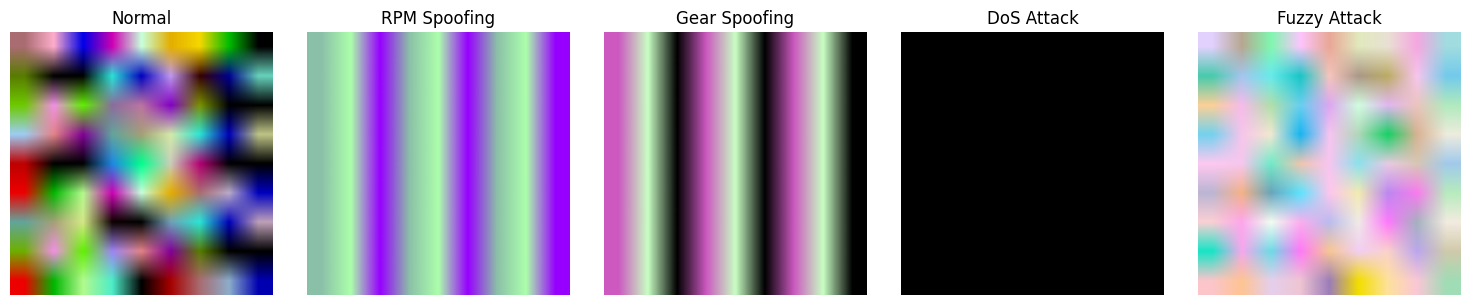

In [30]:
# Create a dictionary to store image paths for each category
categories = {
    "0": "Normal",
    "1": "RPM Spoofing",
    "2": "Gear Spoofing",
    "3": "DoS Attack",
    "4": "Fuzzy Attack",
}

# Get random images from each category
random_images = {}
for category in categories.keys():
    category_path = os.path.join("./train_224/", category)
    # List all png files in the directory
    image_files = [f for f in os.listdir(category_path) if f.endswith(".png")]
    # Select a random image
    if image_files:
        random_image = random.choice(image_files)
        random_images[category] = os.path.join(category_path, random_image)

# Display the random images
plt.figure(figsize=(15, 3))
for i, (category, image_path) in enumerate(random_images.items()):
    img = Image.open(image_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(categories[category])
    plt.axis("off")  # Turn off axis numbers

plt.tight_layout()
plt.show()